# ETL Consolidado: RHR, Movimiento y Hormonas

# ¿Qué hay en este código? (*resúmen hecho con IA*)
---

## Objetivo Principal
Construir un **dataset unificado** (una fila por `(sujeto, día)`) para el período **2022**, integrando:
- Movimiento diario
- Frecuencia cardíaca en reposo (RHR)
- Métricas dinámicas de frecuencia cardíaca intradiaria
- Hormonas (LH, estrógeno, fase del ciclo)
- Temperatura de muñeca (features + PCA)

--- 

## Etapas

### 1. Carga de datos
Se cargan 6 archivos CSV desde la carpeta DBS:
- `active_minutes.csv` → movimiento
- `resting_heart_rate.csv` → RHR diario
- `heart_rate.csv` → BPM cada ~5 segundos
- `hormones_and_selfreport.csv` → hormonas y fase
- `wrist_temperature.csv` → temperatura diferencial
- `computed_temperature.csv` (por agregar)

### 2. Procesamiento de movimiento
- Filtra `study_interval == 2022`
- Calcula `movement_per_day_percentage = 1 - (sedentario/total)`
- Agrupa por `(id, day_in_study)` con media

### 3. RHR diario
- Filtra 2022
- Elimina duplicados por `(id, day_in_study)`
- Renombra `value` a `rhr_value`

### 4. Métricas dinámicas de HR (intradiario)
A partir de multiples mediciones de BPM por día, se calculan:
- `hr_mean`, `hr_sd`, `hr_range`, `hr_cv`
- `hr_mean_abs_delta` (cambio absoluto promedio)
- `hr_sd_delta` (variabilidad de cambios)
- `hr_direction_changes` (cambios de tendencia)
- `hr_path_length` (suma de cambios absolutos)

Luego se aplica **PCA** sobre las 5 métricas para obtener con `hr_pc1, hr_pc2, hr_pc3`

### 5. Hormonas
- Filtra 2022
- Selecciona `lh`, `estrogen`, `phase`
- Agrupa por `(id, day_in_study)`

### 6. Temperatura de muñeca
A partir de series intradiarias de `temperature_diff_from_baseline`:
- Calcula: media, SD, min, max, rango, delta medio, delta SD, path length, percentiles 10/90
- Aplica **PCA** (4 componentes): `wtmp_pc1..wtmp_pc4`

### 7. Consolidación final
Se hace **merge secuencial** (outer join) de:
- movimiento + RHR
- + componentes HR dinámicas
- + hormonas
- + componentes de temperatura

Resultado: **3,698 filas × 10 columnas**, 42 sujetos únicos.

### 8. Control de calidad
- Verificación de duplicados por `(id, day_in_study)`
- Reporte de nulos por columna
- Estadísticas descriptivas
- Guardado en CSV: `mcphases_consolidated_2022.csv`
  
---


# Código

## 1. Setup y Carga de Datos

In [ ]:
from pathlib import Path
from dotenv import load_dotenv
import os


load_dotenv()

DATA_PATH = Path(os.getenv("DATA_PATH"))
OUTPUT_PATH = Path(os.getenv("OUTPUT_PATH"))

print(DATA_PATH)
print(f"Data path: {DATA_PATH}")
print(f"Output path: {OUTPUT_PATH}")

/Users/daragama/DBS/mcphases1.0.0
Data path: /Users/daragama/DBS/mcphases1.0.0
Output path: /Users/daragama/Documents/ProyectosVarios/DTW_mcphases/output


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Cargar CSVs
df_exercise = pd.read_csv(DATA_PATH / "active_minutes.csv")
df_rhr = pd.read_csv(DATA_PATH / "resting_heart_rate.csv")
df_heart_rate = pd.read_csv(DATA_PATH / "heart_rate.csv")  # Para métricas dinámicas
df_hormones = pd.read_csv(DATA_PATH / "hormones_and_selfreport.csv")
df_wrist_temperature = pd.read_csv(DATA_PATH / "wrist_temperature.csv")
df_computed_temperature = pd.read_csv(DATA_PATH / "computed_temperature.csv")

print("Datos cargados:")
print(f"  - Exercise: {df_exercise.shape}")
print(f"  - RHR (diario): {df_rhr.shape}")
print(f"  - Heart Rate (intradiario): {df_heart_rate.shape}")
print(f"  - Hormones: {df_hormones.shape}")

Datos cargados:
  - Exercise: (5552, 8)
  - RHR (diario): (13737, 6)
  - Heart Rate (intradiario): (63100276, 7)
  - Hormones: (5659, 22)


## 2. Procesamiento de Movimiento (Active Minutes)

In [4]:
# Revisar estructura
df_exercise.head()

,id,study_interval,is_weekend,day_in_study,sedentary,lightly,moderately,very
0,1,2022,True,1,753.0,64,0,0
1,1,2022,False,2,855.0,74,0,0
2,1,2022,False,3,751.0,134,18,7
3,1,2022,False,4,905.0,86,0,0
4,1,2022,False,5,1430.0,10,0,0


In [5]:
# Filtrar intervalo 2022 y preparar movimiento
df_movement = (
    df_exercise[df_exercise["study_interval"] == 2022]
    .copy()
)

# Calcular movement_per_day_percentage si no existe
if "movement_per_day_percentage" not in df_movement.columns:
    df_movement["sedentary_percentage"] = (
        df_movement["sedentary"] /
        df_movement[["sedentary", "lightly", "moderately", "very"]].sum(axis=1)
    )
    df_movement["movement_per_day_percentage"] = 1 - df_movement["sedentary_percentage"]

# Asegurar una observación por day_in_study por id
df_movement_daily = (
    df_movement
    .groupby(["id", "day_in_study"], as_index=False)
    .agg({"movement_per_day_percentage": "mean"})
    .rename(columns={"movement_per_day_percentage": "movement_pct"})
)

print(f"Movimiento diario: {df_movement_daily.shape}")
print(f"Sujetos únicos: {df_movement_daily['id'].nunique()}")
df_movement_daily.head()

Movimiento diario: (3698, 3)
Sujetos únicos: 42


,id,day_in_study,movement_pct
0,1,1,0.078335
1,1,2,0.079656
2,1,3,0.174725
3,1,4,0.086781
4,1,5,0.006944


## 3. Procesamiento de Frecuencia Cardíaca en Reposo (RHR)

In [6]:
# Revisar estructura
df_rhr.head()

,id,study_interval,is_weekend,day_in_study,value,error
0,1,2022,True,1,74.785346,100.000000
1,1,2022,False,2,80.407307,29.833838
2,1,2022,False,3,84.686869,24.267298
3,1,2022,False,4,83.852219,10.344703
4,1,2022,False,5,0.000000,0.000000


In [7]:
# Revisar estructura y nulos
print("RHR - Estructura y nulos:")
print(f"Shape: {df_rhr.shape}")
print(f"\nNulos por columna:")
print(df_rhr.isnull().sum())
print(f"\nPrimeras filas:")
print(df_rhr.head())

RHR - Estructura y nulos:
Shape: (13737, 6)

Nulos por columna:
id                0
study_interval    0
is_weekend        0
day_in_study      0
value             0
error             0
dtype: int64

Primeras filas:
   id  study_interval  is_weekend  day_in_study      value       error
0   1            2022        True             1  74.785346  100.000000
1   1            2022       False             2  80.407307   29.833838
2   1            2022       False             3  84.686869   24.267298
3   1            2022       False             4  83.852219   10.344703
4   1            2022       False             5   0.000000    0.000000


In [8]:
# Filtrar intervalo 2022 y preparar RHR diario
df_rhr_2022 = df_rhr[df_rhr["study_interval"] == 2022].copy()

# RHR ya tiene una medición por día, pero verificar duplicados
print(f"RHR 2022: {df_rhr_2022.shape}")
print(f"Sujetos únicos: {df_rhr_2022['id'].nunique()}")
print(f"\nDuplicados (id, day_in_study): {df_rhr_2022.duplicated(subset=['id', 'day_in_study']).sum()}")

# Asegurar una observación por día por id (tomar la primera si hay duplicados)
df_rhr_daily = (
    df_rhr_2022
    .groupby(['id', 'day_in_study'], as_index=False)
    .first()
    .rename(columns={'value': 'rhr_value'}, inplace=False)
)

print(f"\nRHR diario final: {df_rhr_daily.shape}")
print(f"Nulos en value: {df_rhr_daily['rhr_value'].isnull().sum()}")
df_rhr_daily.head()

RHR 2022: (3698, 6)
Sujetos únicos: 42

Duplicados (id, day_in_study): 0

RHR diario final: (3698, 6)
Nulos en value: 0


,id,day_in_study,study_interval,is_weekend,rhr_value,error
0,1,1,2022,True,74.785346,100.000000
1,1,2,2022,False,80.407307,29.833838
2,1,3,2022,False,84.686869,24.267298
3,1,4,2022,False,83.852219,10.344703
4,1,5,2022,False,0.000000,0.000000


## 3.5 Métricas Dinámicas de Heart Rate (intradiario)

In [9]:
# Revisar estructura y nulos
print("Heart Rate - Estructura y nulos:")
print(f"Shape: {df_heart_rate.shape}")
print(f"\nNulos por columna:")
print(df_heart_rate.isnull().sum())
print(f"\nPrimeras filas:")
print(df_heart_rate.head())

Heart Rate - Estructura y nulos:
Shape: (63100276, 7)

Nulos por columna:
id                0
study_interval    0
is_weekend        0
day_in_study      0
timestamp         0
bpm               0
confidence        0
dtype: int64

Primeras filas:
   id  study_interval  is_weekend  day_in_study timestamp  bpm  confidence
0   1            2022        True             1  01:22:09   75           1
1   1            2022        True             1  01:22:14   79           1
2   1            2022        True             1  01:22:19   80           1
3   1            2022        True             1  01:22:24   81           1
4   1            2022        True             1  01:22:29   80           1


In [10]:
# Filtrar intervalo 2022
df_hr_2022 = df_heart_rate[df_heart_rate["study_interval"] == 2022].copy()

print(f"Heart Rate 2022: {df_hr_2022.shape}")
print(f"Sujetos únicos: {df_hr_2022['id'].nunique()}")
print(f"Nulos en bpm: {df_hr_2022['bpm'].isnull().sum()}")

Heart Rate 2022: (39812695, 7)
Sujetos únicos: 41
Nulos en bpm: 0


| Métrica                | Qué captura                          |
| ---------------------- | ------------------------------------ |
| `hr_mean`              | Nivel basal de BPM                   |
| `hr_sd`                | Variabilidad global                  |
| `hr_mean_abs_delta`    | Intensidad promedio de fluctuaciones |
| `hr_sd_delta`          | Irregularidad de las fluctuaciones   |
| `hr_path_length`       | Movimiento total acumulado           |
| `hr_direction_changes` | Frecuencia de oscilaciones           |


In [11]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

def calculate_hr_dynamics(group):

    bpm = group["bpm"].dropna().to_numpy()

    if len(bpm) < 2:
        return pd.Series({
            "hr_mean": np.nan,
            "hr_sd": np.nan,
            "hr_mean_abs_delta": np.nan,
            "hr_sd_delta": np.nan,
            "hr_direction_changes": np.nan,
            "hr_range": np.nan,
            "hr_cv": np.nan,
            "hr_path_length": np.nan
        })

    delta = np.diff(bpm)
    abs_delta = np.abs(delta)

    return pd.Series({
        "hr_mean": np.mean(bpm),
        "hr_sd": np.std(bpm, ddof=1),
        "hr_mean_abs_delta": np.mean(abs_delta),
        "hr_sd_delta": np.std(delta, ddof=1),
        "hr_direction_changes": np.sum(
            np.diff(np.sign(delta)) != 0
        ),
        "hr_range": np.max(bpm) - np.min(bpm),
        "hr_cv": np.std(bpm, ddof=1) / np.mean(bpm),
        "hr_path_length": np.sum(abs_delta)
    })

# Agrupar por id y day_in_study
df_hr_daily_metrics = (
    df_hr_2022
    .groupby(['id', 'day_in_study'], as_index=False)
    .apply(calculate_hr_dynamics, include_groups=False)
)

print(f"Heart Rate dinámico diario: {df_hr_daily_metrics.shape}")
print(f"Sujetos únicos: {df_hr_daily_metrics['id'].nunique()}")
print(f"\nNulos por métrica:")
print(df_hr_daily_metrics.isnull().sum())
df_hr_daily_metrics.head()

Heart Rate dinámico diario: (3483, 10)
Sujetos únicos: 41

Nulos por métrica:
id                      0
day_in_study            0
hr_mean                 0
hr_sd                   0
hr_mean_abs_delta       0
hr_sd_delta             0
hr_direction_changes    0
hr_range                0
hr_cv                   0
hr_path_length          0
dtype: int64


,id,day_in_study,hr_mean,hr_sd,hr_mean_abs_delta,hr_sd_delta,hr_direction_changes,hr_range,hr_cv,hr_path_length
0,1,1,77.641853,11.317769,1.556217,2.189369,4091.0,69.0,0.145769,12291.0
1,1,2,95.732149,20.507059,2.033951,3.192844,4487.0,111.0,0.214213,19111.0
2,1,3,104.158134,19.085520,2.169022,3.400073,5028.0,118.0,0.183236,21944.0
3,1,4,87.039370,11.372742,1.557387,2.094298,3542.0,66.0,0.130662,10679.0
4,1,5,102.900407,24.700893,2.384493,4.018943,3203.0,109.0,0.240047,16422.0


### PCA on HR

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_hr_daily_metrics[["hr_mean", "hr_sd", "hr_mean_abs_delta", "hr_sd_delta", "hr_direction_changes"]].copy()
X = X.interpolate(limit_direction="both")
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained_Var": pca.explained_variance_ratio_,
    "Cumulative": pca.explained_variance_ratio_.cumsum()
})

print(explained)

   PC  Explained_Var  Cumulative
0   1       0.478528    0.478528
1   2       0.236977    0.715505
2   3       0.166952    0.882457
3   4       0.105796    0.988253
4   5       0.011747    1.000000


In [13]:
pca = PCA(n_components=3)

pcs = pca.fit_transform(X_scaled)

df_hr_daily_metrics["hr_pc1"] = pcs[:, 0]
df_hr_daily_metrics["hr_pc2"] = pcs[:, 1]
df_hr_daily_metrics["hr_pc3"] = pcs[:, 2]

df_hr_daily_pca = df_hr_daily_metrics[["id", "day_in_study", "hr_pc1", "hr_pc2", "hr_pc3"]].copy()

In [14]:
df_hr_daily_pca.head()

,id,day_in_study,hr_pc1,hr_pc2,hr_pc3
0,1,1,-0.087502,-1.584184,0.756453
1,1,2,4.716075,0.174529,0.696757
2,1,3,5.546794,0.622128,1.111908
3,1,4,0.130233,-1.319226,1.926947
4,1,5,8.362226,-0.195472,0.846024


## 4. Procesamiento de Hormonas

In [15]:
# Revisar estructura y nulos
print("Hormonas - Estructura y nulos:")
print(f"Shape: {df_hormones.shape}")
print(f"\nNulos por columna:")
print(df_hormones.isnull().sum())
print(f"\nColumnas: {df_hormones.columns.tolist()}")

Hormonas - Estructura y nulos:
Shape: (5659, 22)

Nulos por columna:
id                   0
study_interval       0
is_weekend           0
day_in_study         0
phase                1
lh                 320
estrogen           321
pdg               3795
flow_volume       2470
flow_color        2465
appetite          2329
exerciselevel     2329
headaches         2331
cramps            2332
sorebreasts       2332
fatigue           2328
sleepissue        2330
moodswing         2339
stress            2332
foodcravings      2332
indigestion       2334
bloating          2331
dtype: int64

Columnas: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']


In [16]:
# Filtrar intervalo 2022 y seleccionar LH y Estrógeno
df_hormones_2022 = df_hormones[df_hormones["study_interval"] == 2022].copy()

print(f"Hormonas 2022: {df_hormones_2022.shape}")
print(f"Sujetos únicos: {df_hormones_2022['id'].nunique()}")

# Seleccionar columnas relevantes (LH y Estrógeno)
hormone_cols = [col for col in ["lh", "estrogen", "phase"]]

print(f"\nHormonas disponibles: {hormone_cols}")
print(f"Nulos por hormona:")
for col in hormone_cols:
    print(f"  {col}: {df_hormones_2022[col].isnull().sum()}")

Hormonas 2022: (3698, 22)
Sujetos únicos: 42

Hormonas disponibles: ['lh', 'estrogen', 'phase']
Nulos por hormona:
  lh: 223
  estrogen: 224
  phase: 1


In [17]:
# Preparar dataframe de hormonas: una medición por day_in_study
# Agrupar y tomar la primera si hay múltiples
df_hormones_daily = (
    df_hormones_2022
    .groupby(["id", "day_in_study"], as_index=False)
    .first()
)

# Seleccionar solo id, day_in_study y variables hormonales
hormones_to_keep = ["id", "day_in_study"] + hormone_cols
df_hormones_daily = df_hormones_daily[hormones_to_keep]

print(f"Hormonas diario: {df_hormones_daily.shape}")
print(f"Sujetos únicos: {df_hormones_daily['id'].nunique()}")
print(f"\nNulos por columna:")
print(df_hormones_daily.isnull().sum())
df_hormones_daily.head()

Hormonas diario: (3698, 5)
Sujetos únicos: 42

Nulos por columna:
id                0
day_in_study      0
lh              223
estrogen        224
phase             1
dtype: int64


,id,day_in_study,lh,estrogen,phase
0,1,1,2.9,94.2,Follicular
1,1,2,1.2,226.3,Follicular
2,1,3,3.5,276.8,Follicular
3,1,4,1.8,322.1,Fertility
4,1,5,4.6,244.9,Fertility


## 5. Temperature

In [18]:
# Revisar estructura y nulos
print("Wrist Temperature - Estructura y nulos:")
print(f"Shape: {df_wrist_temperature.shape}")
print(f"\nNulos por columna:")
print(df_wrist_temperature.isnull().sum())
print(f"\nColumnas: {df_wrist_temperature.columns.tolist()}")

Wrist Temperature - Estructura y nulos:
Shape: (6856019, 6)

Nulos por columna:
id                                0
study_interval                    0
is_weekend                        0
day_in_study                      0
timestamp                         0
temperature_diff_from_baseline    0
dtype: int64

Columnas: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'temperature_diff_from_baseline']


Nivel:
- temp_mean
- temp_sd
- temp_min
- temp_max
- temp_range

Dinámica:
- temp_mean_abs_delta
- temp_sd_delta
- temp_path_length

Distribución:
- temp_p10
- temp_p90

In [19]:
# Filtrar intervalo 2022
df_wrist_temperature_2022 = df_wrist_temperature[df_wrist_temperature["study_interval"] == 2022].copy()

print(f"Wrist Temperature 2022: {df_wrist_temperature_2022.shape}")
print(f"Sujetos únicos: {df_wrist_temperature_2022['id'].nunique()}")


print(f"Nulos por columna:")
print(df_wrist_temperature.isnull().sum())

Wrist Temperature 2022: (4215949, 6)
Sujetos únicos: 42
Nulos por columna:
id                                0
study_interval                    0
is_weekend                        0
day_in_study                      0
timestamp                         0
temperature_diff_from_baseline    0
dtype: int64


In [20]:
import numpy as np
import pandas as pd

def calculate_temp_dynamics(group):

    temp = (
        group["temperature_diff_from_baseline"]
        .dropna()
        .to_numpy()
    )

    if len(temp) < 2:
        return pd.Series({
            "temp_mean": np.nan,
            "temp_sd": np.nan,
            "temp_min": np.nan,
            "temp_max": np.nan,
            "temp_range": np.nan,
            "temp_mean_abs_delta": np.nan,
            "temp_sd_delta": np.nan,
            "temp_path_length": np.nan,
            "temp_p10": np.nan,
            "temp_p90": np.nan
        })

    delta = np.diff(temp)

    return pd.Series({
        "temp_mean": np.mean(temp),
        "temp_sd": np.std(temp, ddof=1),
        "temp_min": np.min(temp),
        "temp_max": np.max(temp),
        "temp_range": np.max(temp) - np.min(temp),
        "temp_mean_abs_delta": np.mean(np.abs(delta)),
        "temp_sd_delta": np.std(delta, ddof=1),
        "temp_path_length": np.sum(np.abs(delta)),
        "temp_p10": np.percentile(temp, 10),
        "temp_p90": np.percentile(temp, 90)
    })

In [21]:
df_wrist_temp_daily = (
    df_wrist_temperature_2022
    .groupby(["id", "day_in_study"], as_index=False)
    .apply(
        calculate_temp_dynamics,
        include_groups=False
    )
)

In [22]:
temp_features = [
    "temp_mean",
    "temp_sd",
    "temp_min",
    "temp_max",
    "temp_range",
    "temp_mean_abs_delta",
    "temp_sd_delta",
    "temp_path_length",
    "temp_p10",
    "temp_p90"
]

### PCA

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_wrist_temp_daily[temp_features].copy()
X = X.interpolate(limit_direction="both")
X_scaled = StandardScaler().fit_transform(X)


pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained_Var": pca.explained_variance_ratio_,
    "Cumulative": pca.explained_variance_ratio_.cumsum()
})

print(explained)

   PC  Explained_Var  Cumulative
0   1   4.164627e-01    0.416463
1   2   2.371402e-01    0.653603
2   3   1.326540e-01    0.786257
3   4   1.019589e-01    0.888216
4   5   5.234215e-02    0.940558
5   6   3.621312e-02    0.976771
6   7   1.425354e-02    0.991025
7   8   7.102888e-03    0.998128
8   9   1.872433e-03    1.000000
9  10   1.226754e-17    1.000000


In [24]:
pca = PCA(n_components=4)

pcs = pca.fit_transform(X_scaled)

df_wrist_temp_daily["wtmp_pc1"] = pcs[:, 0]
df_wrist_temp_daily["wtmp_pc2"] = pcs[:, 1]
df_wrist_temp_daily["wtmp_pc3"] = pcs[:, 2]

## 5.2 Computed Temperature

In [25]:
# Revisar estructura y nulos
print("Computed Temperature - Estructura y nulos:")
print(f"Shape: {df_computed_temperature.shape}")
print(f"\nNulos por columna:")
print(df_computed_temperature.isnull().sum())
print(f"\nColumnas: {df_computed_temperature.columns.tolist()}")

Computed Temperature - Estructura y nulos:
Shape: (5575, 14)

Nulos por columna:
id                                                0
study_interval                                    0
is_weekend                                        0
sleep_start_day_in_study                          0
sleep_start_timestamp                             0
sleep_end_day_in_study                            0
sleep_end_timestamp                               0
type                                              0
temperature_samples                               0
nightly_temperature                               0
baseline_relative_sample_sum                    379
baseline_relative_sample_sum_of_squares         379
baseline_relative_nightly_standard_deviation    379
baseline_relative_sample_standard_deviation     379
dtype: int64

Columnas: ['id', 'study_interval', 'is_weekend', 'sleep_start_day_in_study', 'sleep_start_timestamp', 'sleep_end_day_in_study', 'sleep_end_timestamp', 'type', 'temperature_sampl

In [26]:
# Filtrar intervalo 2022
df_computed_temperature_2022 = df_computed_temperature[df_computed_temperature["study_interval"] == 2022].copy()

print(f"Computed Temp 2022: {df_computed_temperature_2022.shape}")
print(f"Sujetos únicos: {df_computed_temperature_2022['id'].nunique()}")


print(f"Nulos por columna:")
print(df_computed_temperature.isnull().sum())

Computed Temp 2022: (3258, 14)
Sujetos únicos: 42
Nulos por columna:
id                                                0
study_interval                                    0
is_weekend                                        0
sleep_start_day_in_study                          0
sleep_start_timestamp                             0
sleep_end_day_in_study                            0
sleep_end_timestamp                               0
type                                              0
temperature_samples                               0
nightly_temperature                               0
baseline_relative_sample_sum                    379
baseline_relative_sample_sum_of_squares         379
baseline_relative_nightly_standard_deviation    379
baseline_relative_sample_standard_deviation     379
dtype: int64


In [27]:
df_computed_temp_daily = (
    df_computed_temperature_2022
    .groupby(["id", "sleep_start_day_in_study"])
    .agg(
        temp_mean=("nightly_temperature", "mean"),
        baseline_nightly_sd=("baseline_relative_nightly_standard_deviation", "mean"),
        baseline_sample_sd=("baseline_relative_sample_standard_deviation", "mean"),
    )
    .reset_index()
)

In [28]:
df_computed_temp_daily.head()
print(df_computed_temp_daily.isnull().sum())
missing = df_computed_temp_daily[
    df_computed_temp_daily["baseline_nightly_sd"].isna()
]

print(missing.head())

id                           0
sleep_start_day_in_study     0
temp_mean                    0
baseline_nightly_sd         62
baseline_sample_sd          62
dtype: int64
     id  sleep_start_day_in_study  temp_mean  baseline_nightly_sd  \
0     1                         1  34.198373                  NaN   
104   3                         1  33.837744                  NaN   
105   3                         2  34.673675                  NaN   
179   4                         2  34.475560                  NaN   
180   4                         3  33.830438                  NaN   

     baseline_sample_sd  
0                   NaN  
104                 NaN  
105                 NaN  
179                 NaN  
180                 NaN  


In [29]:
(
    df_computed_temp_daily["baseline_nightly_sd"].isna()
    ==
    df_computed_temp_daily["baseline_sample_sd"].isna()
).all()

np.True_

ambos faltantes ocurren en las mismas filas

In [30]:
df_computed_temp_daily = (
    df_computed_temp_daily
    .sort_values(["id", "sleep_start_day_in_study"])
)

for col in ["baseline_nightly_sd", "baseline_sample_sd"]:
    df_computed_temp_daily[col] = (
        df_computed_temp_daily
        .groupby("id")[col]
        .transform(lambda x: x.interpolate(limit_direction="both"))
    )

In [31]:
df_computed_temp_daily.rename(columns={"sleep_start_day_in_study": "day_in_study"}, inplace=True)
print(df_computed_temp_daily.isnull().sum())

id                     0
day_in_study           0
temp_mean              0
baseline_nightly_sd    0
baseline_sample_sd     0
dtype: int64


No se usa computed temperature, tiene algunos problemas con falta de datos y podría agregar redundancia con wrist

## 6. Consolidación del Dataframe Final

In [32]:
# Merge de movimiento + RHR diario (valor simple)
df_consolidated = (
    df_movement_daily
    .merge(df_rhr_daily[["id", "day_in_study", "rhr_value"]], 
           on=["id", "day_in_study"], how="outer")
)

print(f"After RHR merge: {df_consolidated.shape}")

# Merge con PCA de dinámicas de Heart Rate
df_consolidated = (
    df_consolidated
    .merge(df_hr_daily_pca, 
           on=["id", "day_in_study"], how="outer")
)

print(f"After HR dynamics merge: {df_consolidated.shape}")

# Merge con hormonas
df_consolidated = (
    df_consolidated
    .merge(df_hormones_daily, 
           on=["id", "day_in_study"], how="outer")
)

print(f"After hormones merge: {df_consolidated.shape}")

# merge con wrist temperature
df_consolidated = (
    df_consolidated
    .merge(df_wrist_temp_daily[["id", "day_in_study", "wtmp_pc1", "wtmp_pc2", "wtmp_pc3"]], 
           on=["id", "day_in_study"], how="outer")
)

print(f"After wrist temperature merge: {df_consolidated.shape}")

# Ordenar por id y day_in_study
df_consolidated = df_consolidated.sort_values(["id", "day_in_study"]).reset_index(drop=True)

print(f"\nDataframe consolidado final: {df_consolidated.shape}")
print(f"Sujetos únicos: {df_consolidated['id'].nunique()}")

After RHR merge: (3698, 4)
After HR dynamics merge: (3698, 7)
After hormones merge: (3698, 10)
After wrist temperature merge: (3698, 13)

Dataframe consolidado final: (3698, 13)
Sujetos únicos: 42


In [33]:
# Ver estructura
print("Primeras filas del dataframe consolidado:")
print(df_consolidated.head(10))
print(f"\nColumnas: {df_consolidated.columns.tolist()}")

Primeras filas del dataframe consolidado:
   id  day_in_study  movement_pct  rhr_value    hr_pc1    hr_pc2    hr_pc3  \
0   1             1      0.078335  74.785346 -0.087502 -1.584184  0.756453   
1   1             2      0.079656  80.407307  4.716075  0.174529  0.696757   
2   1             3      0.174725  84.686869  5.546794  0.622128  1.111908   
3   1             4      0.086781  83.852219  0.130233 -1.319226  1.926947   
4   1             5      0.006944   0.000000  8.362226 -0.195472  0.846024   
5   1             6      0.026316  82.077053  4.788206 -0.530856  1.000721   
6   1             7      0.126898  79.335861  0.442856 -0.682325  1.167039   
7   1             8      0.102778   0.000000  2.520140 -1.910666  3.307995   
8   1             9      0.071429  76.736727  6.235750 -0.571468 -0.012039   
9   1            10      0.074481  76.589839  4.269572  0.353902  0.289978   

    lh  estrogen       phase  wtmp_pc1  wtmp_pc2  wtmp_pc3  
0  2.9      94.2  Follicular       NaN

In [34]:
# Resumen detallado
print("="*60)
print("RESUMEN DE CALIDAD DE DATOS")
print("="*60)

print("\nTamaño final:")
print(f"  - Filas (observaciones): {df_consolidated.shape[0]}")
print(f"  - Columnas (variables): {df_consolidated.shape[1]}")
print(f"  - Sujetos únicos: {df_consolidated['id'].nunique()}")

print("\nMissing values por columna:")
missing_summary = pd.DataFrame({
    'Column': df_consolidated.columns,
    'Missing_Count': df_consolidated.isnull().sum(),
    'Missing_Pct': (df_consolidated.isnull().sum() / len(df_consolidated) * 100).round(2)
})
print(missing_summary.to_string(index=False))

print("\nEstructura del dataframe:")
print(df_consolidated.info())

print("\nEstadísticas descriptivas:")
print(df_consolidated.describe())

RESUMEN DE CALIDAD DE DATOS

Tamaño final:
  - Filas (observaciones): 3698
  - Columnas (variables): 13
  - Sujetos únicos: 42

Missing values por columna:
      Column  Missing_Count  Missing_Pct
          id              0         0.00
day_in_study              0         0.00
movement_pct              0         0.00
   rhr_value              0         0.00
      hr_pc1            215         5.81
      hr_pc2            215         5.81
      hr_pc3            215         5.81
          lh            223         6.03
    estrogen            224         6.06
       phase              1         0.03
    wtmp_pc1            508        13.74
    wtmp_pc2            508        13.74
    wtmp_pc3            508        13.74

Estructura del dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 3698 entries, 0 to 3697
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3698 non-null   int64  
 1   day_in_study 

In [35]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
df_consolidated.describe()

Estadísticas descriptivas:


,id,day_in_study,movement_pct,rhr_value,hr_pc1,hr_pc2,hr_pc3,lh,estrogen,wtmp_pc1,wtmp_pc2,wtmp_pc3
count,3698.000000,3698.000000,3698.000000,3698.000000,3.483000e+03,3.483000e+03,3.483000e+03,3475.000000,3474.000000,3.190000e+03,3.190000e+03,3.190000e+03
mean,25.287182,44.989454,0.200525,53.689706,-1.632025e-17,-8.160123e-18,1.632025e-17,5.335799,138.674036,-5.345776e-17,-1.781925e-17,1.781925e-17
std,15.076875,25.954792,0.133871,28.639029,1.547038e+00,1.088680e+00,9.137834e-01,6.884436,111.993602,2.041062e+00,1.540177e+00,1.151936e+00
min,1.000000,1.000000,0.000000,0.000000,-5.514762e+00,-6.395343e+00,-2.339618e+00,0.000000,0.000000,-5.944851e+00,-1.016087e+01,-1.409720e+01
25%,12.000000,23.000000,0.106320,55.354611,-8.829650e-01,-5.408101e-01,-6.136257e-01,2.500000,67.325000,-1.445630e+00,-1.058757e+00,-7.220289e-01
50%,24.000000,45.000000,0.194460,64.830880,-2.476772e-01,2.086763e-02,-9.325828e-02,3.600000,108.450000,-1.588526e-02,-7.806914e-02,-1.521721e-02
75%,40.000000,67.000000,0.281515,71.789644,5.703461e-01,5.724979e-01,5.590047e-01,5.500000,174.475000,1.312651e+00,9.629670e-01,7.209856e-01
max,50.000000,90.000000,1.000000,88.088963,1.542745e+01,5.271513e+00,6.069407e+00,97.000000,640.000000,8.150514e+00,6.939885e+00,4.552442e+00


In [36]:
df_consolidated.head()

,id,day_in_study,movement_pct,rhr_value,hr_pc1,hr_pc2,hr_pc3,lh,estrogen,phase,wtmp_pc1,wtmp_pc2,wtmp_pc3
0,1,1,0.078335,74.785346,-0.087502,-1.584184,0.756453,2.9,94.2,Follicular,NaN,NaN,NaN
1,1,2,0.079656,80.407307,4.716075,0.174529,0.696757,1.2,226.3,Follicular,NaN,NaN,NaN
2,1,3,0.174725,84.686869,5.546794,0.622128,1.111908,3.5,276.8,Follicular,-4.029523,2.463657,-0.533221
3,1,4,0.086781,83.852219,0.130233,-1.319226,1.926947,1.8,322.1,Fertility,-4.000154,2.382851,-1.749736
4,1,5,0.006944,0.000000,8.362226,-0.195472,0.846024,4.6,244.9,Fertility,NaN,NaN,NaN


## 7. Guardar Resultado

In [37]:
# Verificar una observación por día por id antes de guardar
duplicates = df_consolidated.duplicated(subset=['id', 'day_in_study'], keep=False)
if duplicates.sum() > 0:
    print(f"ADVERTENCIA: Hay {duplicates.sum()} registros duplicados (id, day_in_study)")
    print("Primeros duplicados:")
    print(df_consolidated[duplicates].head())
else:
    print("✓ Confirmado: Una observación por día por sujeto")

# Guardar CSV
output_file = OUTPUT_PATH / "mcphases_consolidated_2022.csv"
df_consolidated.to_csv(output_file, index=False)

print(f"\n✓ Archivo guardado en: {output_file}")
print(f"✓ Shape final: {df_consolidated.shape}")

✓ Confirmado: Una observación por día por sujeto

✓ Archivo guardado en: /Users/daragama/Documents/ProyectosVarios/DTW_mcphases/output/mcphases_consolidated_2022.csv
✓ Shape final: (3698, 13)


In [38]:
print((df_consolidated["rhr_value"] == 0).sum())

782


In [39]:
df_consolidated.loc[df_consolidated["rhr_value"] == 0, "rhr_value"] = np.nan

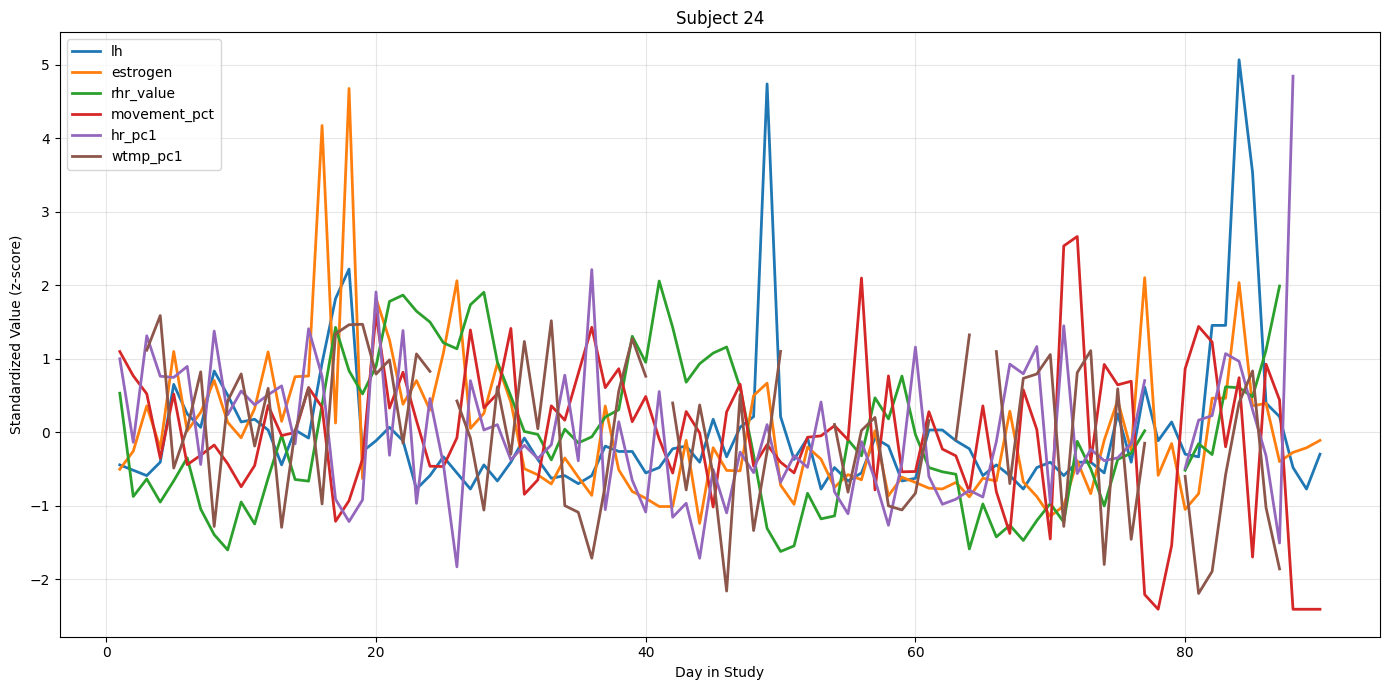

In [40]:
# visualizar 12 series de un sujeto de ejemplo
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

subject_id = 24  # cambia por el sujeto que quieras

cols_to_plot = [
    "lh",
    "estrogen",
    "rhr_value",
    "movement_pct",
    "hr_pc1",
    "wtmp_pc1"
]

df_subject = (
    df_consolidated[df_consolidated["id"] == subject_id]
    .sort_values("day_in_study")
    .copy()
)

# estandarizar cada serie para compararlas visualmente
scaler = StandardScaler()

df_plot = df_subject[cols_to_plot].copy()

for col in cols_to_plot:
    valid = df_plot[col].notna()

    if valid.sum() > 1:
        df_plot.loc[valid, col] = scaler.fit_transform(
            df_plot.loc[valid, [col]]
        ).ravel()

plt.figure(figsize=(14, 7))

for col in cols_to_plot:
    plt.plot(
        df_subject["day_in_study"],
        df_plot[col],
        label=col,
        linewidth=2
    )

plt.xlabel("Day in Study")
plt.ylabel("Standardized Value (z-score)")
plt.title(f"Subject {subject_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


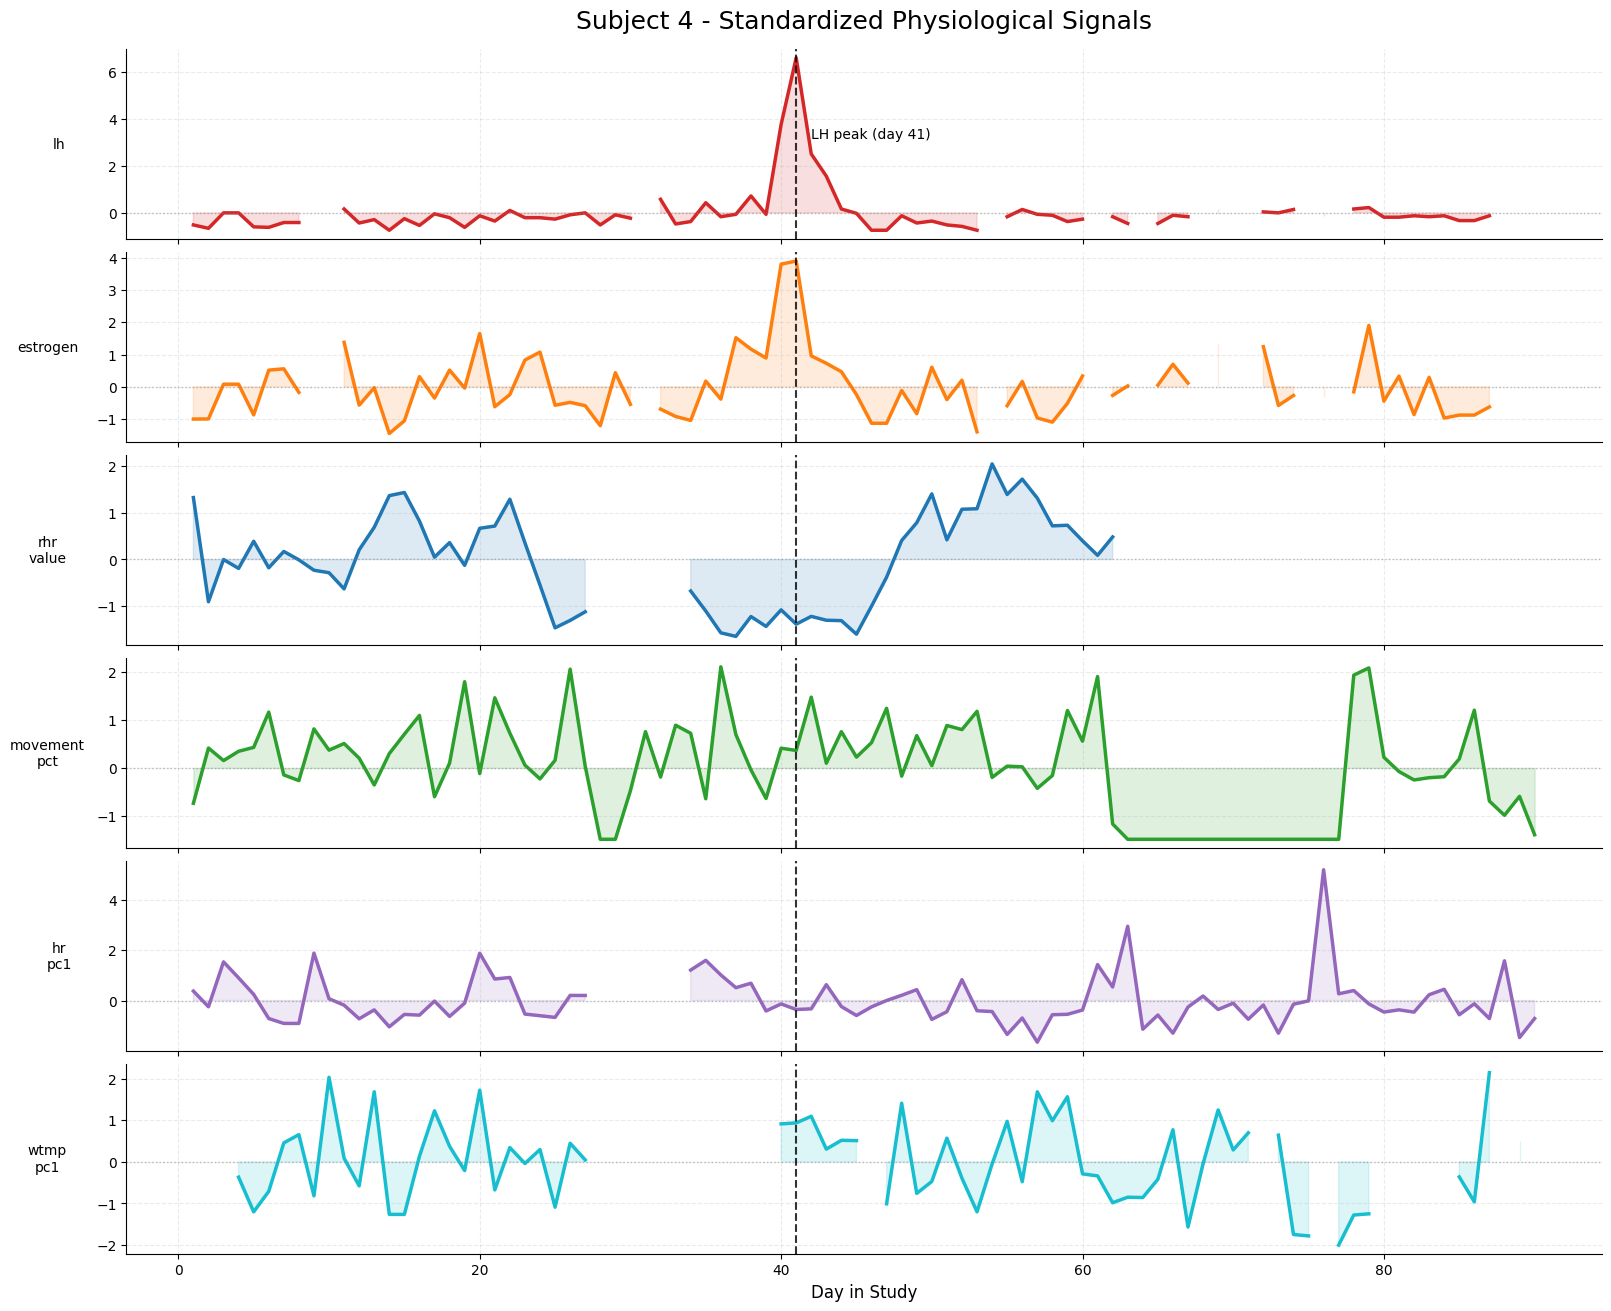

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# =========================
# Seleccionar sujeto
# =========================
subject_id = 4

cols_to_plot = [
    "lh",
    "estrogen",
    "rhr_value",
    "movement_pct",
    "hr_pc1",
    "wtmp_pc1"
]

colors = {
    "lh": "#d62728",          # rojo
    "estrogen": "#ff7f0e",    # naranja
    "rhr_value": "#1f77b4",   # azul
    "movement_pct": "#2ca02c",# verde
    "hr_pc1": "#9467bd",      # morado
    "wtmp_pc1": "#17becf"     # cyan
}

# =========================
# Filtrar sujeto
# =========================
df_subject = (
    df_consolidated[df_consolidated["id"] == subject_id]
    .sort_values("day_in_study")
    .copy()
)

# =========================
# Estandarizar cada serie
# =========================
for col in cols_to_plot:
    df_subject[f"{col}_z"] = zscore(
        df_subject[col],
        nan_policy="omit"
    )

# =========================
# Día del pico de LH
# =========================
lh_peak_day = None

if df_subject["lh"].notna().any():
    lh_peak_day = (
        df_subject.loc[
            df_subject["lh"].idxmax(),
            "day_in_study"
        ]
    )

# =========================
# Graficar
# =========================
fig, axes = plt.subplots(
    nrows=len(cols_to_plot),
    ncols=1,
    figsize=(16, 13),
    sharex=True,
    constrained_layout=True
)

for ax, col in zip(axes, cols_to_plot):

    y = df_subject[f"{col}_z"]
    color = colors[col]

    ax.plot(
        df_subject["day_in_study"],
        y,
        color=color,
        linewidth=2.5
    )

    ax.fill_between(
        df_subject["day_in_study"],
        y,
        color=color,
        alpha=0.15
    )

    ax.axhline(
        0,
        linestyle=":",
        linewidth=1,
        alpha=0.5,
        color="gray"
    )

    if lh_peak_day is not None:
        ax.axvline(
            lh_peak_day,
            color="black",
            linestyle="--",
            linewidth=1.5,
            alpha=0.8
        )

    ax.set_ylabel(
        col.replace("_", "\n"),
        rotation=0,
        labelpad=35,
        fontsize=10,
        va="center"
    )

    ax.grid(
        alpha=0.25,
        linestyle="--"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ax.set_ylim(-4, 4)

axes[0].set_title(
    f"Subject {subject_id} - Standardized Physiological Signals",
    fontsize=18,
    pad=15
)

if lh_peak_day is not None:
    axes[0].text(
        lh_peak_day + 1,
        3.2,
        f"LH peak (day {lh_peak_day})",
        fontsize=10
    )

axes[-1].set_xlabel(
    "Day in Study",
    fontsize=12
)

plt.savefig(f"{OUTPUT_PATH}/subject_{subject_id}_physio_signals.png", dpi=300)
plt.show()